# 🔗 第 58 课 · Triton 与 vLLM

> vLLM 为什么用 triton 写注意力 kernel?从 backend 注册表到 block table,再到一个能跑的 mini paged attention

**章节**: 第 9 章 · Triton 编程

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 看懂 vLLM v1 的 TritonAttentionBackend 结构(vendor/vllm 源码)
- 理解 vLLM 选 triton 而非纯 C++/flash-attn 的工程原因
- 掌握 paged attention 的 block table + KV cache 内存布局思路
- 手写一个 mini triton paged decode attention kernel 并与 torch 对拍验证

## 📑 本课目录

1. **直觉:注意力后端是一份“定制菜单”** — 一个 attention,多个实现,按需插拔
2. **为什么 vLLM 用 triton 写注意力 kernel** — 可移植、可维护、可定制:80% 性能换 100% 灵活性
3. **读源码:TritonAttentionBackend 骨架** — vendor/vllm 里真实的后端类与核心方法
4. **block table:一张“书签”对抗碎片化** — 逻辑页 → 物理块的映射思想
5. **KV cache 的内存布局** — K/V 打包、slot_mapping 写、block_table 读
6. **动手:mini triton paged decode attention** — 一个 program 处理一个 (seq, head),online softmax 滚块
7. **前端:从 query 到 kernel 的一次旅行** — forward() 里元数据怎么流进 unified_attention
8. **配套 Streamlit 演示** — app_58_triton_vllm.py:后端选择 + 内存布局交互示意

## 🔗 参考资料

- [vLLM 注意力后端文档](https://docs.vllm.ai/en/latest/design/attention.html)
- [triton_attn.py 源码(本机 vendor/vllm)](file:///D:/Project/21-Cpp_learn/explore/vendor/vllm/vllm/v1/attention/backends/triton_attn.py)
- [PagedAttention v1 论文](https://arxiv.org/abs/2309.06180)
- [FlashAttention 论文](https://arxiv.org/abs/2205.14135)

## 1️⃣ 直觉:注意力后端是一份“定制菜单” 📋

vLLM 的注意力**不是一个固定实现**,而是一组可插拔的**后端(backend)**。翻开
`vllm/v1/attention/backends/` 目录,你能看到:flash_attn.py、triton_attn.py、flashinfer.py、
mla.py、cpu_attn.py……每个文件都是一个“厨师团队”,做着同一道菜(attention),但用不同的
**菜谱(kernel)**。

推理时,`registry.py` 根据模型架构、GPU、环境变量 `VLLM_ATTENTION_BACKEND` 等,选一个后端出来。
**Triton 后端**(`triton_attn.py`)是其中特别的一员:它不依赖任何 C++ 扩展,整个注意力 kernel
几乎全部用 **Triton(Python)** 写成,编译到 GPU。这一课我们就把它拆开看。

✅ 环境自检:本课要真实编译一个 mini paged attention kernel,先设好 ptxas。

In [1]:
# -*- coding: utf-8 -*-
# 环境自检:KMP 防护 + 指定可用 ptxas + 打印 GPU/triton 信息
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")          # Windows OMP 冲突防护
_PTXAS = r"D:\CUDA\v13.3\bin\ptxas.exe"                     # 系统 CUDA 自带 ptxas
if os.path.exists(_PTXAS):                                      # 内嵌 ptxas 在本机编译失败
    os.environ["TRITON_PTXAS_PATH"] = _PTXAS
import math, time
import numpy as np
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", font=["Microsoft YaHei", "DejaVu Sans"])
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200

torch.manual_seed(0)
print("torch   :", torch.__version__)
print("triton  :", triton.__version__)
print("CUDA    :", torch.cuda.is_available())
print("GPU     :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")
print("ptxas   :", os.environ.get("TRITON_PTXAS_PATH", "内嵌"))

torch   : 2.11.0+cu128
triton  : 3.7.1
CUDA    : True
GPU     : NVIDIA GeForce RTX 5060 Laptop GPU
ptxas   : D:\CUDA\v13.3\bin\ptxas.exe


## 2️⃣ 为什么 vLLM 用 triton 写注意力 kernel 🧐

对比两条路:

- **flash-attn(C++/CUDA)**:性能天花板高,但每次要适配新 GPU 架构、加新功能(FP8、滑动窗口、
  per-token-head 量化)都要动 C++、重新编译扩展;
- **Triton(Python)**:一套源码自动适配各代 GPU,功能在 Python 层就能改,开发迭代飞快。

vLLM 的取舍是:**80% 的峰值性能,换 100% 的灵活性与可维护性**。具体到 `triton_attn.py`,
它支持的“非主流”需求包括:

| 能力 | 说明 |
|------|------|
| `block_size` 任意 **16 的倍数** | 页粒度更灵活,显存利用率更高 |
| FP8 / INT4 per-token-head 量化 KV cache | 量化格式自己用 triton 写 |
| 滑动窗口 / alibi / sink token | 长文本与多模态场景 |
| 批大小不变性(batch-invariance) | CUDA Graph 友好 |
| 纯 Python 可调 | 出 bug 好定位、好改 |

这些在 C++ 里都是“动一发牵全身”的改动,在 Triton 里只是改几行 Python。

## 3️⃣ 读源码:TritonAttentionBackend 骨架 🗂️

打开本机 vendor 源码:
`D:\Project\21-Cpp_learn\explore\vendor\vllm\vllm\v1\attention\backends\triton_attn.py`。

核心结构是两层类:**Backend(选型/元数据)+ Impl(真正的 forward)**。下面摘录几个关键片段:

```python
# Backend 层:声明支持什么、KV cache 长什么样
class TritonAttentionBackend(AttentionBackend):
    supported_dtypes = [torch.float16, torch.bfloat16, torch.float32]
    supported_kv_cache_dtypes = ["auto", "float16", "bfloat16", "fp8", ...]

    @staticmethod
    def get_name() -> str:
        return "TRITON_ATTN"

    @staticmethod
    def get_kv_cache_shape(num_blocks, block_size, num_kv_heads, head_size, ...):
        # K 和 V 打包进最后一维:逻辑形状 (B, H, N, 2*hs)
        return (num_blocks, num_kv_heads, block_size, 2 * head_size)
```

```python
# Impl 层:真正的前向,一步到位
class TritonAttentionImpl(AttentionImpl):
    def forward(self, layer, query, key, value, kv_cache, attn_metadata, output, ...):
        # ...
        unified_attention(
            q=query, k=key_cache, v=value_cache, out=output,
            cu_seqlens_q=attn_metadata.query_start_loc,   # 每条序列的 token 起点
            seqused_k=attn_metadata.seq_lens,             # 每条序列已缓存的 token 数
            block_table=attn_metadata.block_table,        # 物理块号表 ← 主角
            max_seqlen_q=..., max_seqlen_k=...,
            softmax_scale=self.scale, causal=attn_metadata.causal, ...)
        return output
```

注意最后一段:**前向的全部信息都打包在 `attn_metadata` 里**(序列长度、起点、block table),
kernel 只认这几个张量——这正是 paged attention 能在固定内存布局上跑的保证。

## 4️⃣ block table:一张“书签”对抗碎片化 📑

为什么需要 block table?因为**序列长度动态变化**:有的序列 300 个 token,有的 3000 个。
如果按“序列”连续分配显存,长序列来临时要么搬动、要么留下内部碎片。

Paged 思路(第 45 课讲过):把 KV 按**固定大小块(block_size)**分配,像内存分页一样。每一条序列
维护一张 **block table**:第 $j$ 页的 KV 存在第 $table[j]$ 号物理块里。查询第 $i$ 个 token 的 KV:
先算 $i \div block\_size$ 得到页号 $p$,再从表里取物理块号 $table[p]$,最后算块内偏移。

用 numpy 演示“按页收集”:把逻辑序列拼出来,验证顺序正确:

🎯 核心:KV 在显存里是“乱序”的,但 block table 保证了**逻辑顺序**永远正确——这就是分页的全部魔法。

In [2]:
import numpy as np

num_blocks, block_size = 8, 4          # 8 个物理块,每块 4 个槽
# 物理块内容:每块里放着“槽的全局编号”,便于对账
kv_cache = np.arange(num_blocks * block_size).reshape(num_blocks, block_size)
print("物理块 1 的 4 个槽:", kv_cache[1])
print("物理块 5 的 4 个槽:", kv_cache[5])
print("物理块 2 的 4 个槽:", kv_cache[2])

# 假设 seq0 的 KV 被散落在物理块 [1, 5, 2](逻辑页 0/1/2),共 10 个 token
block_table = np.array([1, 5, 2])
seq_len = 10

# 按 block table 逐页收集,得到“逻辑序列”(末页可能不满,先收全 12 槽再截断)
logical_full = np.concatenate([kv_cache[p] for p in block_table])
logical = logical_full[:seq_len]
print("按 block table 拼出的逻辑序列:", logical)

# 逐页对账:第 p 页的内容必须恰好等于物理块 block_table[p]
ok = all(np.array_equal(logical_full[p * block_size:(p + 1) * block_size], kv_cache[block_table[p]])
         for p in range(len(block_table)))
print("逐页对账:第 p 页内容 == 物理块 block_table[p] ?", ok)

物理块 1 的 4 个槽: [4 5 6 7]
物理块 5 的 4 个槽: [20 21 22 23]
物理块 2 的 4 个槽: [ 8  9 10 11]
按 block table 拼出的逻辑序列: [ 4  5  6  7 20 21 22 23  8  9]
逐页对账:第 p 页内容 == 物理块 block_table[p] ? True


## 5️⃣ KV cache 的内存布局 📦

vLLM 的 KV cache 张量形状是:

```
kv_cache: (num_blocks, num_kv_heads, block_size, 2 * head_size)
```

即 **K、V 打包在最后一维**。写缓存用 `slot_mapping`(每个 token 唯一槽位),读缓存用
`block_table`(每序列按页读)。一写一读,配合起来就是完整生命周期:

- **写(reshape_and_cache)**:新 token 的 K/V 按 `slot_mapping[token]` 找到槽位写入;
- **读(paged attention)**:kernel 按 `block_table[seq][页]` 逐块取回 KV。

这两个操作在 `triton_attn.py` 里分别是 `triton_reshape_and_cache_flash` 与 `unified_attention`。
我们用一张图示意内存布局(2 个块,块大小 16,2 个 KV 头,head_size=64):

🎨 一个物理块 = 一条“页”:block_size 个 token 的 K 与 V 并排躺着。

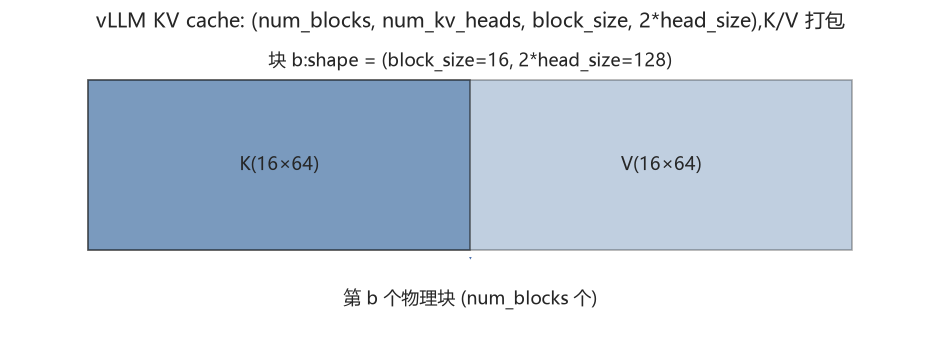

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.add_patch(plt.Rectangle((0, 0), 1, 1, color="#4C78A8", alpha=0.35, ec="k"))
ax.add_patch(plt.Rectangle((0, 0), 0.5, 1, color="#4C78A8", alpha=0.6, ec="k"))
ax.text(0.25, 0.5, "K(16×64)", ha="center", va="center", fontsize=11)
ax.text(0.75, 0.5, "V(16×64)", ha="center", va="center", fontsize=11)
ax.text(0.5, 1.08, "块 b:shape = (block_size=16, 2*head_size=128)",
        ha="center", fontsize=11)
ax.annotate("", xy=(0.5, -0.12), xytext=(0.5, 0), arrowprops=dict(arrowstyle="-|>", lw=2))
ax.text(0.5, -0.32, "第 b 个物理块 (num_blocks 个)",
        ha="center", fontsize=11)
ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.6, 1.25); ax.axis("off")
ax.set_title("vLLM KV cache: (num_blocks, num_kv_heads, block_size, 2*head_size),K/V 打包",
             fontsize=12)
plt.tight_layout()

## 6️⃣ 动手:mini triton paged decode attention ⚡

现在把上面的思想写成一个**能跑、能验证**的 triton kernel——这是 `triton_attn.py` 里
decode 路径的“教学缩小版”:

- **grid = (bs × nheads,)**:一个 program 处理一条序列的一个 head;
- 每 program 只有一个 **query token**(decode 阶段每序列每步只生成一个 token);
- 沿 `block_table` **逐块扫描**,用 **online softmax**(m/l/acc)在块间滚动;
- 尾部不满一个块时用 **mask 读入**,并把多余行的 score 设成 `-inf`(防止“幽灵行”污染 softmax)。

这段代码里 `tl.load(block_table + seq_id * max_blocks + bi)` 就是第 4 节“按页收集”的 kernel 版。

📐 完整 kernel + wrapper。注意几个关键点:exp 用 `tl.exp`(别用 exp2 否则 softmax 变温标),尾部行必须 mask 成 -inf。

In [4]:
@triton.jit
def paged_decode_attn_kernel(
    q_ptr, k_cache_ptr, v_cache_ptr, o_ptr, block_table_ptr,
    seq_len_ptr, scale, num_kv_heads, max_blocks,
    BLOCK_SIZE: tl.constexpr, BLOCK_D: tl.constexpr):
    """mini 版 triton paged decode attention(教学用)。
    一个 program 处理一条序列的一个 head;Q 是单个 token(query),
    K/V 从按物理块组织的 KV cache 里通过 block_table 收集。
    - k_cache / v_cache: (num_blocks, num_kv_heads, block_size, head_size)
    - block_table: (num_seqs, max_blocks),记录每条序列的物理块号
    - seq_len_ptr: 每条序列当前 token 数
    内部用 online softmax(m/l/acc)在块间滚动,数学与 FlashAttention 一致。"""
    pid = tl.program_id(0)
    seq_id = pid // num_kv_heads
    head_id = pid % num_kv_heads
    q_offs = seq_id * num_kv_heads * BLOCK_D + head_id * BLOCK_D + tl.arange(0, BLOCK_D)
    q = tl.load(q_ptr + q_offs)                          # (BLOCK_D,) 单个 query
    seq_len = tl.load(seq_len_ptr + seq_id)
    m = tl.full([1], float("-inf"), dtype=tl.float32)    # running max
    l = tl.zeros([1], dtype=tl.float32)                  # running sum
    acc = tl.zeros([BLOCK_D], dtype=tl.float32)          # 输出累加器
    num_full = seq_len // BLOCK_SIZE                     # 完整块数
    for bi in range(0, max_blocks):                      # 逐块扫描物理块
        if bi < num_full:
            block_id = tl.load(block_table_ptr + seq_id * max_blocks + bi)
            base = block_id * num_kv_heads * BLOCK_SIZE * BLOCK_D + head_id * BLOCK_SIZE * BLOCK_D
            rows = tl.arange(0, BLOCK_SIZE)[:, None]
            cols = tl.arange(0, BLOCK_D)[None, :]
            kk = tl.load(k_cache_ptr + base + rows * BLOCK_D + cols)   # (BS, D)
            s = tl.sum(q[None, :] * kk, axis=1) * scale  # 块内打分 (BS,)
            m_new = tl.maximum(m, tl.max(s))             # 更新 max
            p = tl.exp(s - m_new)                        # 归一化(exp 而非 exp2!)
            alpha = tl.exp(m - m_new)                    # 旧累加校正系数
            l = l * alpha + tl.sum(p)
            vv = tl.load(v_cache_ptr + base + rows * BLOCK_D + cols)
            acc = acc * alpha + tl.sum(p[:, None] * vv, axis=0)
            m = m_new
    if seq_len % BLOCK_SIZE != 0:                        # 尾部不满一块:mask 读入
        block_id = tl.load(block_table_ptr + seq_id * max_blocks + num_full)
        base = block_id * num_kv_heads * BLOCK_SIZE * BLOCK_D + head_id * BLOCK_SIZE * BLOCK_D
        rows = tl.arange(0, BLOCK_SIZE)
        cols = tl.arange(0, BLOCK_D)
        mask = rows[:, None] < (seq_len - num_full * BLOCK_SIZE)
        kk = tl.load(k_cache_ptr + base + rows[:, None] * BLOCK_D + cols[None, :],
                     mask=mask, other=0.0)
        s = tl.sum(q[None, :] * kk, axis=1) * scale
        s = tl.where(rows < (seq_len - num_full * BLOCK_SIZE), s, float("-inf"))  # 关键:掩掉多余行
        m_new = tl.maximum(m, tl.max(s))
        p = tl.exp(s - m_new)
        alpha = tl.exp(m - m_new)
        l = l * alpha + tl.sum(p)
        vv = tl.load(v_cache_ptr + base + rows[:, None] * BLOCK_D + cols[None, :],
                     mask=mask, other=0.0)
        acc = acc * alpha + tl.sum(p[:, None] * vv, axis=0)
        m = m_new
    acc = acc / l                                        # 除以分母
    tl.store(o_ptr + q_offs, acc)


def paged_decode_attn(q, k_cache, v_cache, block_table, seq_lens, head_size, block_size=16):
    """wrapper:q (bs, nheads, hs);k_cache/v_cache (num_blocks, nkv, bs, hs);
    block_table (bs, max_blocks);seq_lens (bs,)。返回 out (bs, nheads, hs)。"""
    bs, nheads, hs = q.shape
    max_blocks = block_table.shape[1]
    out = torch.empty_like(q)
    grid = (bs * nheads,)
    paged_decode_attn_kernel[grid](
        q, k_cache, v_cache, out, block_table, seq_lens, hs ** -0.5, nheads, max_blocks,
        BLOCK_SIZE=block_size, BLOCK_D=head_size)
    return out

✅ 编译并运行 mini paged decode attention。接下来与 torch 参考实现对拍。

In [5]:
torch.manual_seed(0)
bs, nheads, hs, block_size = 3, 4, 64, 16      # 3 条序列,4 个头
num_blocks = 64
k_cache = torch.randn(num_blocks, nheads, block_size, hs, device="cuda") * 0.1
v_cache = torch.randn(num_blocks, nheads, block_size, hs, device="cuda") * 0.1

# 序列长度:40 / 17 / 3 -> 需要的块数 ceil(len/16) = 3 / 2 / 1
seq_lens = torch.tensor([40, 17, 3], device="cuda", dtype=torch.int32)
nb = 3
block_table = torch.tensor([[0, 1, 2], [10, 11, 12], [20, 21, 22]], device="cuda", dtype=torch.int32)

# 把“真实” KV 内容写进物理块(内容存于 kv_k/kv_v,物理位置由 block_table 决定)
kv_k = torch.randn(bs, nb, nheads, block_size, hs, device="cuda") * 0.1
kv_v = torch.randn(bs, nb, nheads, block_size, hs, device="cuda") * 0.1
for s in range(bs):
    for b in range(nb):
        k_cache[block_table[s, b].item()] = kv_k[s, b]
        v_cache[block_table[s, b].item()] = kv_v[s, b]

q = torch.randn(bs, nheads, hs, device="cuda") * 0.1
out = paged_decode_attn(q, k_cache, v_cache, block_table, seq_lens, hs, block_size)
torch.cuda.synchronize()
print("kernel 输出形状:", tuple(out.shape))

kernel 输出形状: (3, 4, 64)


🎯 这个对拍就是第 59 课“对拍验证”的实战预演——先小规模、逐块对齐,再相信 kernel。误差 ~1e-8 说明分页、online softmax、尾部 mask 全部正确。

In [6]:
# torch 参考实现:按 block_table 收集每条序列的 KV,再算单 token attention
ref = torch.zeros_like(q)
for s in range(bs):
    n = seq_lens[s].item()
    for h in range(nheads):
        K = kv_k[s][:nb][:, h].reshape(-1, hs)[:n]     # 注意:先选 head 再 reshape!
        V = kv_v[s][:nb][:, h].reshape(-1, hs)[:n]
        svec = (q[s, h] * K).sum(-1) * (hs ** -0.5)
        p = torch.softmax(svec, dim=0)
        ref[s, h] = (p[:, None] * V).sum(0)

err = (out - ref).abs().max().item()
print(f"max err = {err:.3e}  (期望 ~1e-8)")
for s in range(bs):
    e = (out[s] - ref[s]).abs().max().item()
    print(f"  seq{s} (len={seq_lens[s].item()}): err = {e:.2e}")

max err = 2.235e-08  (期望 ~1e-8)
  seq0 (len=40): err = 7.45e-09
  seq1 (len=17): err = 7.45e-09
  seq2 (len=3): err = 2.24e-08


## 7️⃣ 前端:从 query 到 kernel 的一次旅行 🧳

把第 3 节和第 6 节串起来,decode 一整个 step 的注意力大概走这几步:

1. **写缓存**:新 token 的 K/V 经 `triton_reshape_and_cache_flash` 写入 `slot_mapping` 指向的槽位;
2. **元数据**:scheduler 把 `seq_lens / block_table / query_start_loc` 填进 `attn_metadata`;
3. **读缓存**:`forward()` 里 `kv_cache.transpose(1,2).split(hs, -1)` 把 K、V 拆开;
4. **算注意力**:`unified_attention(...)` 一次性拿到 query、KV cache 与元数据,按
   `block_table` 逐页扫描——和我们 mini kernel 的原理完全一致;
5. **输出**:`output[:num_actual_tokens]` 直接作为下一层的输入。

关键区别只在规模:真实 vLLM 的 `unified_attention` 要处理 CUDA Graph 捕获、per-token-head
量化、多模态前缀、滑动窗口等,而我们的 mini kernel 抓住了**最核心的骨架**。

## 8️⃣ 配套 Streamlit 演示:后端选择交互示意 🎛️

运行同目录下的 `app_58_triton_vllm.py`,切换 **后端 / 物理块数 / 块大小 / 批大小**,实时观察
KV cache 的形状、显存占用、每条序列分到的块,以及 block table 的逐页映射:

```bash
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_58_triton_vllm.py
```

浏览器打开 **http://localhost:8501**。建议把批大小调大,看序列如何被切分到各物理块。
完整源码如下(与同目录 `app_58_triton_vllm.py` 一字不差):

📜 app_58_triton_vllm.py 完整源码:纯模拟(不编译 kernel),重点在把 block table 的内存布局“画”出来。

In [7]:
%%writefile app_58_triton_vllm.py
# -*- coding: utf-8 -*-
# app_58_triton_vllm.py — 后端选择 + block table 交互示意 🔗
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import streamlit as st
import plotly.graph_objects as go
import numpy as np
import pandas as pd

st.set_page_config(page_title="Triton 与 vLLM 🔗", layout="wide")
st.title("🔗 第 58 课 · Triton 与 vLLM:后端选择与 block table")

st.markdown("""
vLLM 的注意力不是一个“固定实现”,而是一组可以**插拔的后端(backend)**。选不同的后端,
推理时就会调用不同的 kernel。本页模拟 vLLM 的 KV cache 内存布局:切换后端、拖动
**物理块数 / 块大小 / 批大小**,实时观察 KV cache 的形状、显存占用与 block table 的映射。
""")

BACKENDS = {
    "TRITON_ATTN": {
        "kernel": "unified_attention + triton_reshape_and_cache_flash",
        "lang": "Triton(Python 编译到 GPU)",
        "note": "vLLM 自己维护的 triton 后端,支持 FP8 KV cache、任意 16 倍数块大小、滑动窗口与 alibi。",
    },
    "FLASH_ATTN": {
        "kernel": "flash_attn_varlen_func(C++/CUDA)",
        "lang": "flash-attn 扩展库",
        "note": "NVIDIA 手写优化的 FlashAttention,峰值性能高,但功能定制需动 C++。",
    },
    "FLASHINFER": {
        "kernel": "flashinfer 的 paged attention",
        "lang": "C++/CUDA + 自研 JIT",
        "note": "高性能第三方库,专为服务场景优化,支持丰富的 page 模式。",
    },
    "MLA": {
        "kernel": "MLA 专属 kernel(MLA 后端)",
        "lang": "混合(C++/CUDA + Triton)",
        "note": "针对 DeepSeek 系 MLA 架构的专用后端,压缩 KV cache 并复用吸收矩阵。",
    },
}

# ---------------------------------------------------------------- 侧边栏参数
with st.sidebar:
    st.header("🎛️ 参数")
    backend = st.selectbox("Attention 后端", list(BACKENDS.keys()))
    num_blocks = st.slider("物理块总数(num_blocks)", 32, 512, 128, 16)
    block_size = st.selectbox("块大小(block_size, 16 的倍数)", [16, 32, 64])
    num_kv_heads = st.slider("KV 头数(num_kv_heads)", 1, 8, 4, 1)
    head_size = st.selectbox("头维度(head_size)", [64, 128])
    batch = st.slider("并发序列数(batch)", 1, 16, 8, 1)
    st.caption("TRITON_ATTN 要求 block_size 是 16 的倍数;块数决定显存里能存多少 token。")

# ---------------------------------------------------------------- KV cache 形状与显存
# TRITON_ATTN: K/V 打包在最后一维,shape = (num_blocks, num_kv_heads, block_size, 2*head_size)
per_block_tokens = block_size * num_kv_heads
kv_bytes = num_blocks * num_kv_heads * block_size * 2 * head_size * 2   # fp16 = 2 字节
max_tokens = num_blocks * block_size

# 模拟:为 batch 条序列分配物理块(顺序分配,便于可视化)
blocks_per_seq = max(1, num_blocks // max(batch, 1))
table = []
for s in range(batch):
    table.append(list(range(s * blocks_per_seq, min((s + 1) * blocks_per_seq, num_blocks))))

c1, c2, c3, c4 = st.columns(4)
c1.metric("KV cache 张量形状", f"({num_blocks}, {num_kv_heads}, {block_size}, {2 * head_size})")
c2.metric("KV cache 显存(fp16)", f"{kv_bytes / 2 ** 20:.1f} MB")
c3.metric("可缓存 token 总量", max_tokens)
c4.metric("每条序列分到块数", blocks_per_seq)

st.subheader(f"🧠 后端:{backend} —— {BACKENDS[backend]['kernel']}")
st.info(BACKENDS[backend]["note"])

# ---------------------------------------------------------------- KV cache 布局热力图(plotly)
st.subheader("🗺️ KV cache 布局:每个格子是一个 (块, 槽位) 槽")
z = np.zeros((num_blocks, block_size))
colors = ["#4C78A8", "#E45756", "#F2C14E", "#72B7B2", "#76B7B2", "#8C5B9E", "#59A14F", "#B6992D"]
for s in range(batch):
    for b in table[s]:
        z[b, :] = s + 1
fig = go.Figure(go.Heatmap(
    z=z, y=[f"块 {i}" for i in range(num_blocks)], x=[f"槽 {i}" for i in range(block_size)],
    colorscale="Viridis", showscale=False,
    hoverongaps=False))
fig.update_layout(title="x 轴=块内槽位(block_size 个 token),y 轴=物理块;同色 = 同一条序列",
                  height=max(300, num_blocks * 6), margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig, use_container_width=True)
st.caption("⭐ 观察:每一条序列只占据“整数块”的内存,序列间的空隙不会超过一个块——这就是 paged 思路对抗碎片化的方法。")

# ---------------------------------------------------------------- block table 表格
st.subheader("📇 block table(物理块号映射)")
st.markdown("每条序列一行,第 j 列 = 它逻辑上第 j 页对应的**物理块号**:")
st.write(pd.DataFrame(table, columns=[f"页{j}" for j in range(blocks_per_seq)],
                      index=[f"seq{s}" for s in range(batch)]))

st.markdown("""
> 💡 **读图方法**:vLLM 的 decode 路径正是用这张表做“按页收集”——
> kernel 里 `tl.load(block_table + seq_id * max_blocks + bi)` 逐页读物理块,拼出完整 KV 序列。
> 后端换到 FLASH_ATTN / FLASHINFER 时,只是换了 kernel 和页表格式,思路不变。
""")

Overwriting app_58_triton_vllm.py


## ✅ 本课小结

- vLLM 的注意力是后端插拔架构:registry 按模型/GPU/环境变量选中某个 backend 并实例化
- triton_attn.py 分 Backend(声明能力)与 Impl(真正 forward)两层,forward 一次调用 unified_attention
- vLLM 选 triton 的工程理由:可移植、可维护、可定制(FP8/滑动窗口/量化),80% 性能换 100% 灵活性
- paged 思路 = 固定大小物理块 + 每序列一张 block table:逻辑顺序永远正确,显存碎片化被控制在块粒度
- mini triton paged decode attention 跑通并对拍误差 ~1e-8,验证了 block table + online softmax + 尾部 mask 整套思路

## ✍️ 动手练习

1. 把 mini kernel 的 head_size 改成 128,重新对拍——BLOCK_D 仍是 2 的幂,应该直接通过
2. 给 block_table 加一点“乱序”(块号打散),验证对拍仍然成立,体会分页的意义
3. 在 kernel 里把 tl.exp 换回 tl.exp2,观察误差如何变大(软max 变温标),理解第 6 节注释
4. 读一读 vendor/vllm 里 triton_reshape_and_cache_flash 的签名,说出 slot_mapping 的用途

## 🔗 延伸阅读

- [vLLM 注意力后端实现(v1/attention/backends)](https://github.com/vllm-project/vllm/blob/main/vllm/v1/attention/backends/)
- [PagedAttention 论文](https://arxiv.org/abs/2309.06180)
- [vLLM 官方文档:设计思想](https://docs.vllm.ai/en/latest/design/)

---
> 🎉 恭喜完成本课!下一课见!